<div style="margin-bottom: 32px;">
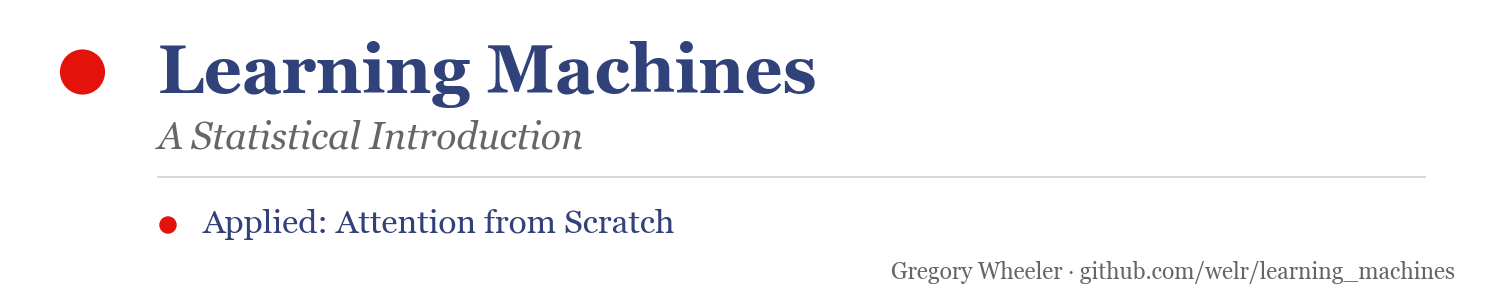
</div>


# Applied — Attention from Scratch

Rung three, the keystone. Here you build the two pieces the GPT capstone of Chapter 12 assembles: a self-attention **`Head`** and a transformer **`Block`**. You will first watch attention compute on a concrete input—seeing the causal mask make it look only backward—then train a one-head model on a tiny task and watch it *learn where to look*.

The **🔧 Your turn** cell is the attention head itself: the exact code you will drop into the GPT next chapter.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt

plt.style.use("mlone_style.mplstyle")
mt.set_notebook_mode()
torch.manual_seed(0); np.random.seed(0)

## The attention head

A single head of self-attention (Chapter 11): project each position to a query, key, and value; score every query against every key and scale by $\sqrt{d_k}$; mask the future so a position sees only itself and the past; softmax into weights; return the weighted sum of the values.

**🔧 Your turn.** Implement `Head.forward`—the scaled, causally masked attention you analyzed in Exercises 11.1–11.3 and 11.9. The reference below also stashes the attention matrix so we can look at it.

In [2]:
class Head(nn.Module):
    """One head of causal self-attention; stores its weights so we can inspect them."""
    def __init__(self, n_embd, head_size, block_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.attn_weights = None

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        weights = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5      # scaled scores
        weights = weights.masked_fill(self.tril[:T, :T] == 0, float("-inf"))   # causal mask
        weights = F.softmax(weights, dim=-1)                         # rows sum to 1
        self.attn_weights = weights.detach()                         # keep for plotting
        return weights @ self.value(x)

## See it compute

Feed a short sequence through an (untrained) head and look at the attention matrix. Entry $(i, j)$ is how much position $i$ attends to position $j$. The causal mask makes it lower-triangular—every position attends only to itself and earlier ones—and each row sums to one (Exercise 11.9).

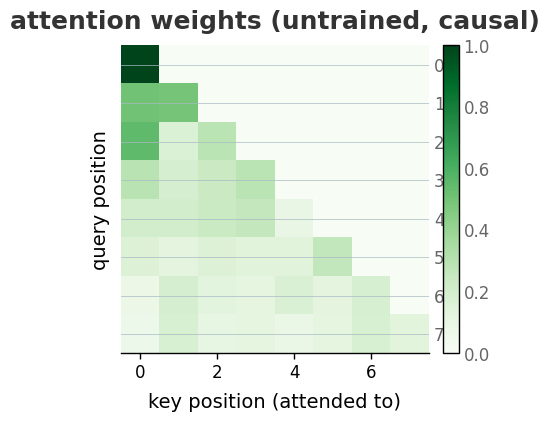

In [3]:
block_size, n_embd = 8, 32
demo_head = Head(n_embd, n_embd, block_size)
x = torch.randn(1, block_size, n_embd)          # one random sequence of 8 positions
demo_head(x)
A = demo_head.attn_weights[0]                    # (T, T)

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(A, cmap="Greens", vmin=0, vmax=1)
ax.set_xlabel("key position (attended to)"); ax.set_ylabel("query position")
ax.set_title("attention weights (untrained, causal)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## From a head to a transformer block

Multi-head attention runs several heads in parallel and concatenates them (Exercise 11.7); a transformer block wraps multi-head attention and a feed-forward network in residual connections and layer normalization (Exercise 11.4)—the residual you built in Chapter 10. These reference implementations are the same classes the capstone uses.

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size, n_embd, block_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(n_embd, head_size, block_size) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, n_embd)

    def forward(self, x):
        return self.proj(torch.cat([h(x) for h in self.heads], dim=-1))


class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.ReLU(), nn.Linear(4 * n_embd, n_embd))

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        self.attn = MultiHeadAttention(n_head, n_embd // n_head, n_embd, block_size)
        self.ffwd = FeedForward(n_embd)
        self.norm1 = nn.LayerNorm(n_embd); self.norm2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))     # residual around attention
        x = x + self.ffwd(self.norm2(x))     # residual around feed-forward
        return x

## Does it learn where to look?

Attention is only useful if the network can learn *what* to attend to. Here is a task that forces the issue: at every position, predict the **first token** of the sequence. The only way to know the first token at position $t$ is to look back to position $0$—so a causal head must learn to attend there. We train with the same loop as Chapters 9 and 10.

In [5]:
V, T = 12, 8
def get_batch(batch=64):
    x = torch.randint(0, V, (batch, T))
    y = x[:, 0:1].expand(batch, T).contiguous()      # target = the first token, at every position
    return x, y

class RecallModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok = nn.Embedding(V, n_embd)
        self.pos = nn.Embedding(T, n_embd)
        self.head = Head(n_embd, n_embd, T)
        self.norm = nn.LayerNorm(n_embd)
        self.out = nn.Linear(n_embd, V)

    def forward(self, x, y=None):
        B, Tt = x.shape
        h = self.tok(x) + self.pos(torch.arange(Tt))
        h = self.norm(self.head(h))
        logits = self.out(h)
        loss = None if y is None else F.cross_entropy(logits.reshape(-1, V), y.reshape(-1))
        return logits, loss

model = RecallModel()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
for step in range(601):
    x, y = get_batch()
    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    if step % 150 == 0:
        with torch.no_grad():
            xv, yv = get_batch(256)
            logits, _ = model(xv)
            acc = (logits.argmax(-1) == yv).float().mean().item()
        print(f"step {step:3d} | loss {loss.item():.3f} | accuracy {acc:.3f}")

step   0 | loss 2.562 | accuracy 0.071
step 150 | loss 0.010 | accuracy 1.000


step 300 | loss 0.004 | accuracy 1.000
step 450 | loss 0.002 | accuracy 1.000


step 600 | loss 0.001 | accuracy 1.000


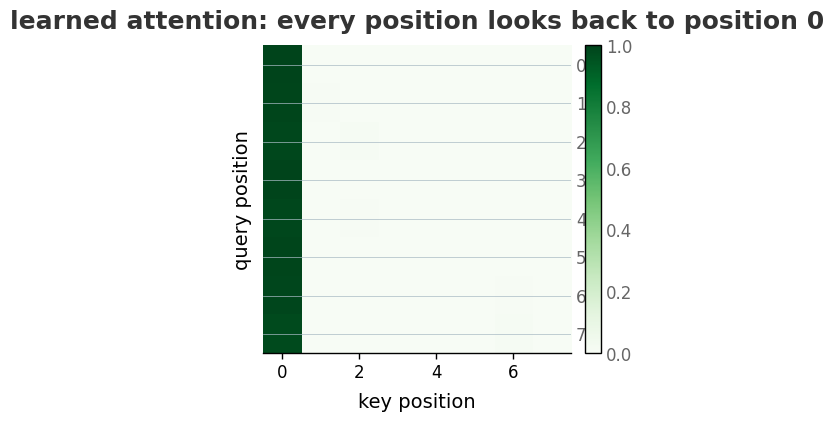

In [6]:
with torch.no_grad():
    xv, _ = get_batch(256)
    model(xv)
A = model.head.attn_weights.mean(0)              # average attention over the batch, (T, T)

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(A, cmap="Greens", vmin=0, vmax=1)
ax.set_xlabel("key position"); ax.set_ylabel("query position")
ax.set_title("learned attention: every position looks back to position 0")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## What you've built

You now have the `Head` and the `Block`—and you have seen attention *learn* to route information from one position to another, something neither the MLP of Chapter 9 nor the convolution of Chapter 10 can do in a content-dependent way. The learned weights concentrate on position $0$ because that is where the answer lives; given a different task, the head would learn to look elsewhere.

**The capstone.** In Chapter 12 you stack these exact blocks into a GPT and train it on real text with the same loop you have now used three times. The only differences are scale and data—you have already written every part.

## Try next

- **Change the target** to the *previous* token (shift the sequence right by one) and retrain; the learned attention should move to the sub-diagonal—each position looking one step back.
- **Remove the causal mask** (let every position see the whole sequence) and predict the *last* token instead; where does the attention go?
- **Add a second head**, or swap the single `Head` for the full `Block`, and see whether the heads specialize.